In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style = 'whitegrid', font_scale = 1.1)
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
df = pd.read_csv('data/raw/dataset.csv')

df.info(), df.describe(), df['track_genre'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

(None,
           Unnamed: 0     popularity   duration_ms   danceability  \
 count  114000.000000  114000.000000  1.140000e+05  114000.000000   
 mean    56999.500000      33.238535  2.280292e+05       0.566800   
 std     32909.109681      22.305078  1.072977e+05       0.173542   
 min         0.000000       0.000000  0.000000e+00       0.000000   
 25%     28499.750000      17.000000  1.740660e+05       0.456000   
 50%     56999.500000      35.000000  2.129060e+05       0.580000   
 75%     85499.250000      50.000000  2.615060e+05       0.695000   
 max    113999.000000     100.000000  5.237295e+06       0.985000   
 
               energy            key       loudness           mode  \
 count  114000.000000  114000.000000  114000.000000  114000.000000   
 mean        0.641383       5.309140      -8.258960       0.637553   
 std         0.251529       3.559987       5.029337       0.480709   
 min         0.000000       0.000000     -49.531000       0.000000   
 25%         0.47200

In [3]:
df = df.drop_duplicates(subset=['track_id'], keep = 'first')

audio_features = [
    'danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'popularity'
]

# оставлю только топ-10 жанров, иначе мультикласс будет слишком размыт
top_genres = df['track_genre'].value_counts().nlargest(10).index
df = df[df['track_genre'].isin(top_genres)].copy()

print(f'Оставлено треков: {len(df)}')
print(f'Жанры для классификации: {top_genres.tolist()}')

Оставлено треков: 9987
Жанры для классификации: ['acoustic', 'afrobeat', 'alt-rock', 'ambient', 'cantopop', 'tango', 'bluegrass', 'chicago-house', 'disney', 'forro']


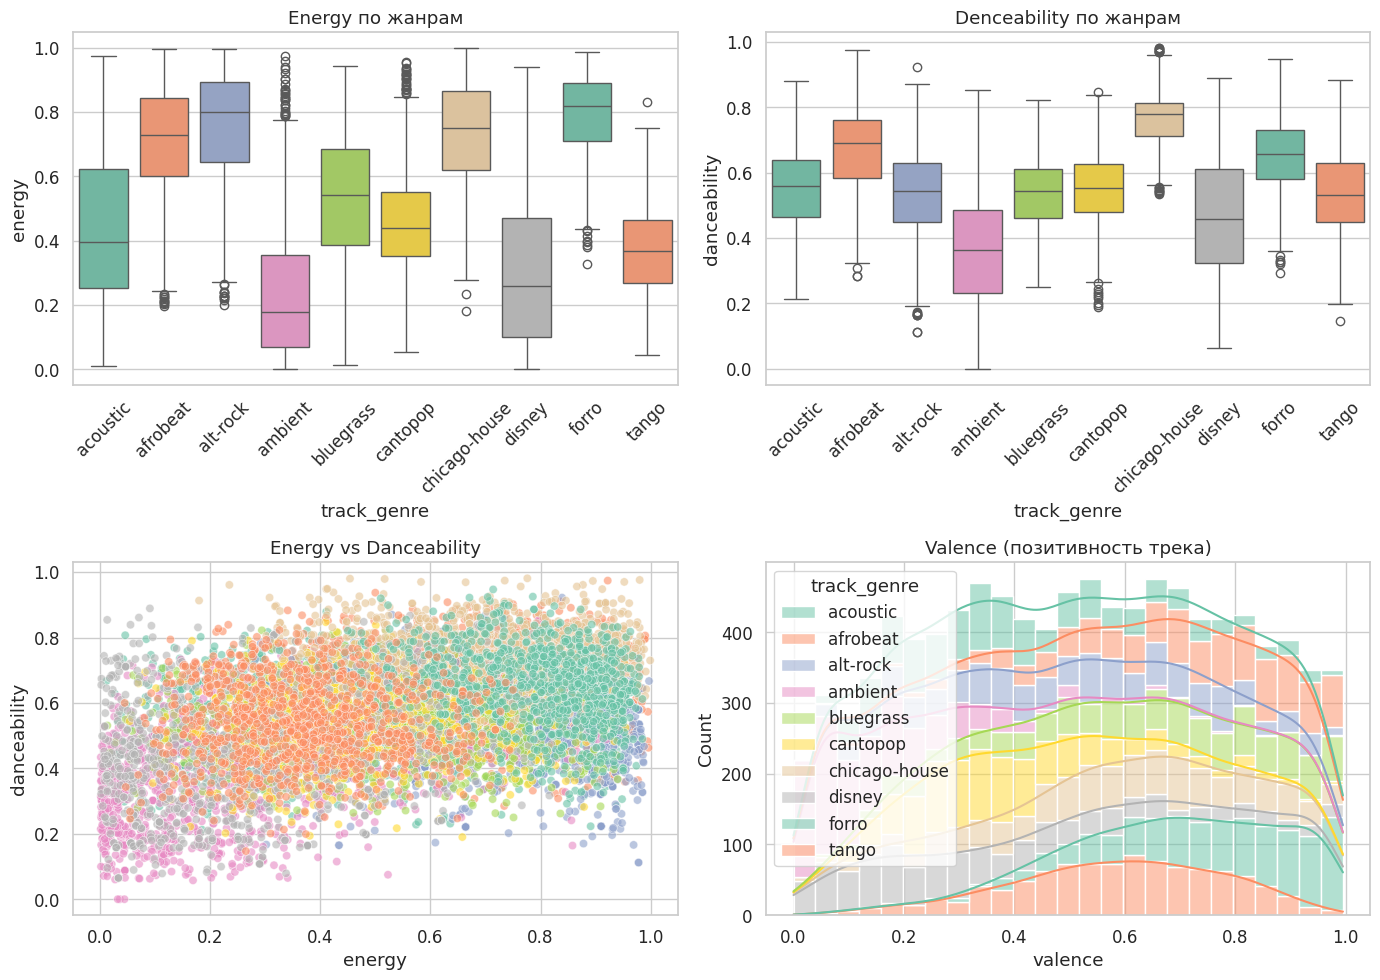

In [4]:
fig, axes = plt.subplots(2, 2, figsize = (14, 10))

sns.boxplot(data = df, x = 'track_genre', y = 'energy', hue='track_genre', ax = axes[0, 0], palette='Set2')
axes[0,0].set_title('Energy по жанрам')
axes[0,0].tick_params(axis = 'x', rotation = 45)

sns.boxplot(data = df, x = 'track_genre', y = 'danceability', hue='track_genre' ,ax=axes[0,1], palette = 'Set2')
axes[0,1].set_title('Denceability по жанрам')
axes[0,1].tick_params(axis = 'x', rotation = 45)

sns.scatterplot(data=df, x='energy', y='danceability', hue='track_genre', 
                ax=axes[1,0], alpha=0.6, palette='Set2', legend=False)
axes[1,0].set_title('Energy vs Danceability')

sns.histplot(data = df, x = 'valence', hue = 'track_genre', kde=True,
            ax = axes[1,1], palette = 'Set2', multiple = 'stack')
axes[1,1].set_title('Valence (позитивность трека)')

plt.tight_layout()
plt.show()

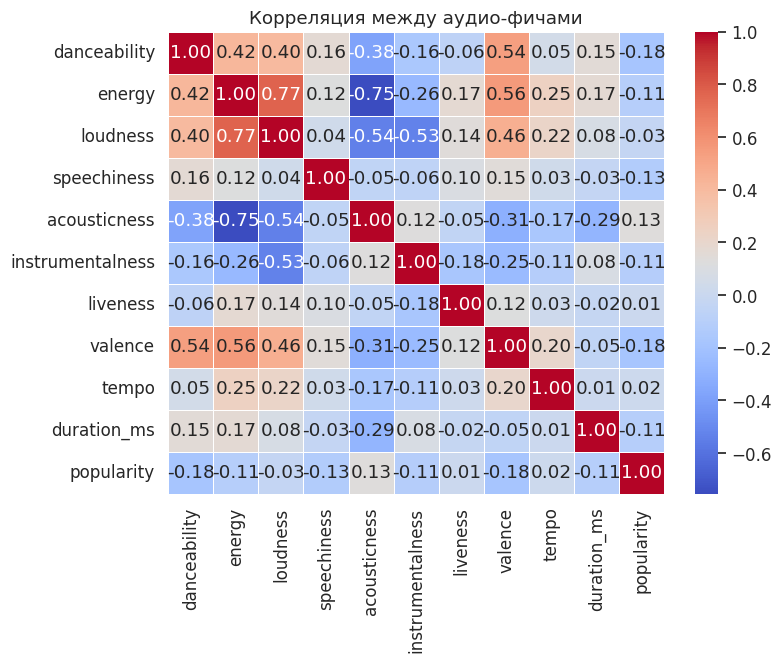

In [5]:
plt.figure(figsize = (8,6))
corr = df[audio_features].corr()
sns.heatmap(corr, annot = True, cmap = 'coolwarm', fmt='.2f', linewidths = 0.5)
plt.title('Корреляция между аудио-фичами')
plt.show()

In [6]:
df_clean = df[audio_features + ['track_genre']].copy()
df_clean = df_clean.dropna()

os.makedirs('data/processed', exist_ok = True)
df_clean.to_csv('data/processed/spotify_clean.csv', index = False)
print('Готово! Очищенный датасет сохранён в data/processed/spotify_clean.csv')


Готово! Очищенный датасет сохранён в data/processed/spotify_clean.csv
